# Bias-Variance Tradeoff

In this notebook, we will understand one of the most important concepts in Machine Learning:

**Bias-Variance Tradeoff**

We will learn:

1. What is Bias?
2. What is Variance?
3. Bias vs Variance
4. Relationship with Underfitting and Overfitting
5. Training Error and Test Error
6. Bias-Variance Tradeoff
7. Model Complexity and Bias/Variance
8. Visualization of Bias and Variance
9. Practical Example
10. How to Reduce Bias
11. How to Reduce Variance
12. Final Summary
13. Quick Revision

We will also implement these concepts using Python and scikit-learn.

## 2. Import Required Libraries

We will use:

- NumPy for numerical calculations
- Pandas for data handling
- Matplotlib for visualization
- Scikit-learn for machine learning models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## 3. What is Bias?

**Bias** is the error caused by making overly simple assumptions about the data.

A model with high bias is usually too simple to capture the underlying pattern.

### High Bias

A high-bias model generally:

- Makes strong assumptions
- Is too simple
- Cannot capture complex patterns
- Performs poorly even on training data

This usually leads to **underfitting**.

### Example

Suppose the actual relationship between X and y is curved:

    y = x²

If we use a simple linear model:

    y = ax + b

the model may not be able to capture the curved relationship.

Therefore, the model will have high bias.

In [2]:
# Create sample data

np.random.seed(42)

X = np.linspace(-5, 5, 100)

y = X**2 + np.random.normal(0, 3, 100)

X = X.reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 1)
Shape of y: (100,)


In [3]:
# Create a simple linear regression model

linear_model = LinearRegression()

linear_model.fit(X, y)

y_pred = linear_model.predict(X)

print("Training MSE:", mean_squared_error(y, y_pred))

Training MSE: 67.68206054438686


## Visualization

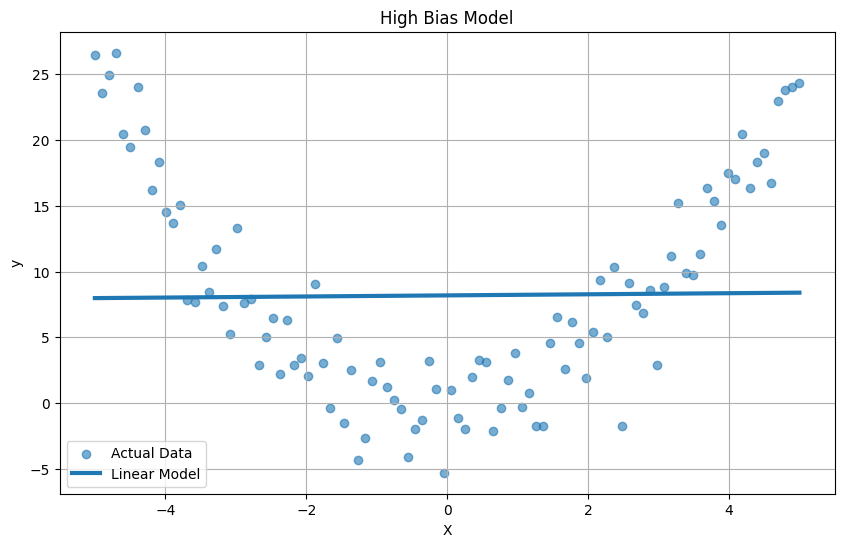

In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, alpha=0.6, label="Actual Data")
plt.plot(X, y_pred, linewidth=3, label="Linear Model")

plt.xlabel("X")
plt.ylabel("y")
plt.title("High Bias Model")

plt.legend()
plt.grid(True)
plt.show()

### Observation

The actual relationship is curved, but the linear model can only learn a straight line.

Therefore:

**Simple model → High Bias → Underfitting**

## 4. What is Variance?

**Variance** describes how much a model's predictions change when the training data changes.

A model with high variance is usually too complex.

### High Variance

A high-variance model generally:

- Learns the training data too closely
- Captures noise
- Changes significantly with different training datasets
- Performs very well on training data
- Performs poorly on unseen data

This usually leads to **overfitting**.

### Simple idea

If a model changes drastically when we slightly change the training data, it has high variance.

In [5]:
# Generate two slightly different datasets

np.random.seed(42)

X1 = np.linspace(-5, 5, 20)
y1 = X1**2 + np.random.normal(0, 3, 20)

X2 = np.linspace(-5, 5, 20)
y2 = X2**2 + np.random.normal(0, 3, 20)

X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)

# High-degree polynomial model

model1 = make_pipeline(
    PolynomialFeatures(degree=15),
    LinearRegression()
)

model2 = make_pipeline(
    PolynomialFeatures(degree=15),
    LinearRegression()
)

model1.fit(X1, y1)
model2.fit(X2, y2)

x_plot = np.linspace(-5, 5, 300).reshape(-1, 1)

pred1 = model1.predict(x_plot)
pred2 = model2.predict(x_plot)

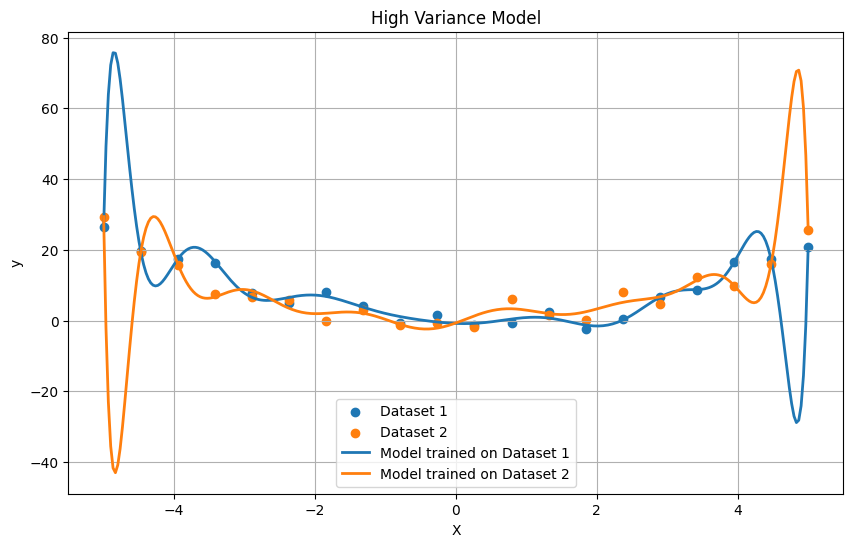

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(X1, y1, label="Dataset 1")
plt.scatter(X2, y2, label="Dataset 2")

plt.plot(x_plot, pred1, linewidth=2, label="Model trained on Dataset 1")
plt.plot(x_plot, pred2, linewidth=2, label="Model trained on Dataset 2")

plt.xlabel("X")
plt.ylabel("y")
plt.title("High Variance Model")

plt.legend()
plt.grid(True)
plt.show()

### Observation

The two models can produce very different curves even though the datasets are similar.

This indicates **high variance**.

**Complex model → High Variance → Overfitting**

## 5. Bias vs Variance

| Bias | Variance |
|------|----------|
| Error from overly simple assumptions | Error from sensitivity to training data |
| High bias → Underfitting | High variance → Overfitting |
| Model is too simple | Model is too complex |
| Poor training performance | Excellent training performance |
| Poor test performance | Poor test performance |

The goal is to find a model that has a good balance between bias and variance.

In [7]:
# Simple conceptual comparison

comparison = pd.DataFrame({
    "Property": [
        "Model complexity",
        "Training error",
        "Test error",
        "Typical problem"
    ],
    "High Bias": [
        "Low",
        "High",
        "High",
        "Underfitting"
    ],
    "High Variance": [
        "High",
        "Low",
        "High",
        "Overfitting"
    ]
})

comparison

,Property,High Bias,High Variance
0,Model complexity,Low,High
1,Training error,High,Low
2,Test error,High,High
3,Typical problem,Underfitting,Overfitting


## 6. Relationship with Underfitting and Overfitting

Bias and variance are closely related to underfitting and overfitting.

### Underfitting

Underfitting occurs when a model is too simple.

**High Bias + Low Variance**

Example:

- Linear model for a highly nonlinear relationship

### Good Fit

The model captures the important pattern without learning unnecessary noise.

**Balanced Bias + Variance**

### Overfitting

Overfitting occurs when a model is too complex.

**Low Bias + High Variance**

Example:

- Very high-degree polynomial model

In [8]:
# Create training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Underfitting model
underfit_model = make_pipeline(
    PolynomialFeatures(degree=1),
    LinearRegression()
)

# Good fit model
good_fit_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

# Overfitting model
overfit_model = make_pipeline(
    PolynomialFeatures(degree=15),
    LinearRegression()
)

# Train models
underfit_model.fit(X_train, y_train)
good_fit_model.fit(X_train, y_train)
overfit_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",15
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [9]:
# Predictions

underfit_pred = underfit_model.predict(X_test)
good_fit_pred = good_fit_model.predict(X_test)
overfit_pred = overfit_model.predict(X_test)

print("Underfitting MSE:",
      mean_squared_error(y_test, underfit_pred))

print("Good Fit MSE:",
      mean_squared_error(y_test, good_fit_pred))

print("Overfitting MSE:",
      mean_squared_error(y_test, overfit_pred))

Underfitting MSE: 58.91587699531051
Good Fit MSE: 5.57669740535548
Overfitting MSE: 7.7803480117069865


## 7. Training Error and Test Error

Two important measurements are:

### Training Error

Error calculated using the training dataset.

### Test Error

Error calculated using unseen test data.

A useful model should perform well on both.

### Typical patterns

**Underfitting**

Training Error → High  
Test Error → High

**Good Fit**

Training Error → Low  
Test Error → Low

**Overfitting**

Training Error → Very Low  
Test Error → High

In [10]:
models = {
    "Underfitting": underfit_model,
    "Good Fit": good_fit_model,
    "Overfitting": overfit_model
}

results = []

for name, model in models.items():

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_error = mean_squared_error(
        y_train,
        train_prediction
    )

    test_error = mean_squared_error(
        y_test,
        test_prediction
    )

    results.append({
        "Model": name,
        "Training Error": train_error,
        "Test Error": test_error
    })

results_df = pd.DataFrame(results)

results_df

,Model,Training Error,Test Error
0,Underfitting,70.235754,58.915877
1,Good Fit,7.742320,5.576697
2,Overfitting,6.437565,7.780348


## 8. Bias-Variance Tradeoff

The **Bias-Variance Tradeoff** describes the balance between:

- Bias
- Variance
- Model complexity

As model complexity increases:

- Bias generally decreases
- Variance generally increases

If the model is too simple:

**High Bias → Underfitting**

If the model is too complex:

**High Variance → Overfitting**

The best model usually lies somewhere in between.

## Conceptual Diagram

```text
Error
 ^
 |\
 | \        Total Error
 |  \      /\
 |   \    /  \
 |    \  /    \
 |     \/      \
 |     /\       \
 |    /  \       \
 |   /    \       \
 |  /      \       \
 +------------------------> Model Complexity
       ↑
   Good Balance

## 9. Model Complexity and Bias/Variance

We can use polynomial regression to demonstrate model complexity.

The polynomial degree controls model complexity.

### Degree 1

Very simple model → High Bias

### Degree 2–3

Usually more flexible → Better fit

### Very high degree

Very complex model → High Variance

In [11]:
degrees = range(1, 16)

train_errors = []
test_errors = []

for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_errors.append(
        mean_squared_error(y_train, train_prediction)
    )

    test_errors.append(
        mean_squared_error(y_test, test_prediction)
    )

## Error vs Complexity

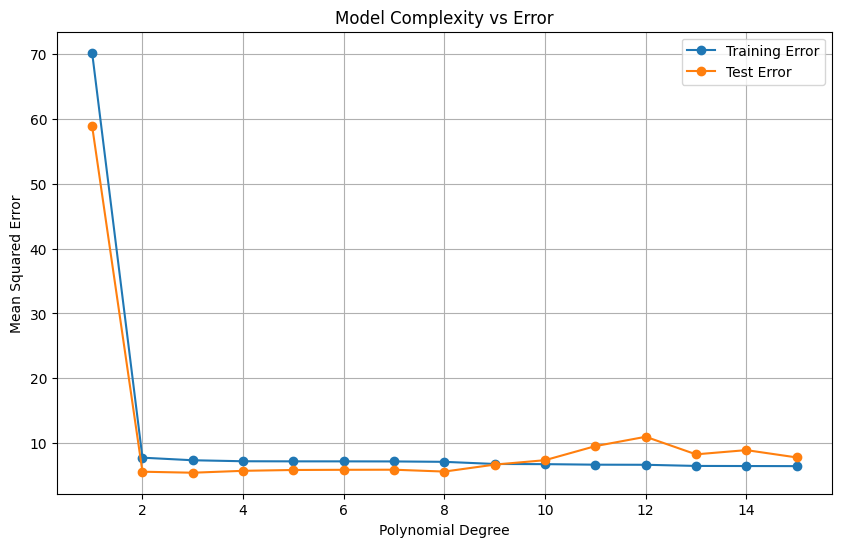

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test Error"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Model Complexity vs Error")

plt.legend()
plt.grid(True)
plt.show()

### Interpretation

At low complexity:

- Training error is high
- Test error is high
- Bias is high

As complexity increases:

- Training error decreases
- Test error initially decreases

After a certain point:

- Training error continues decreasing
- Test error starts increasing

This is the beginning of overfitting.

The minimum point of the test-error curve represents a good balance between bias and variance.

## 10. Visualization of Bias and Variance

We can visualize the general relationship between:

- Model complexity
- Bias
- Variance

This is a conceptual visualization rather than an exact measurement of bias and variance.

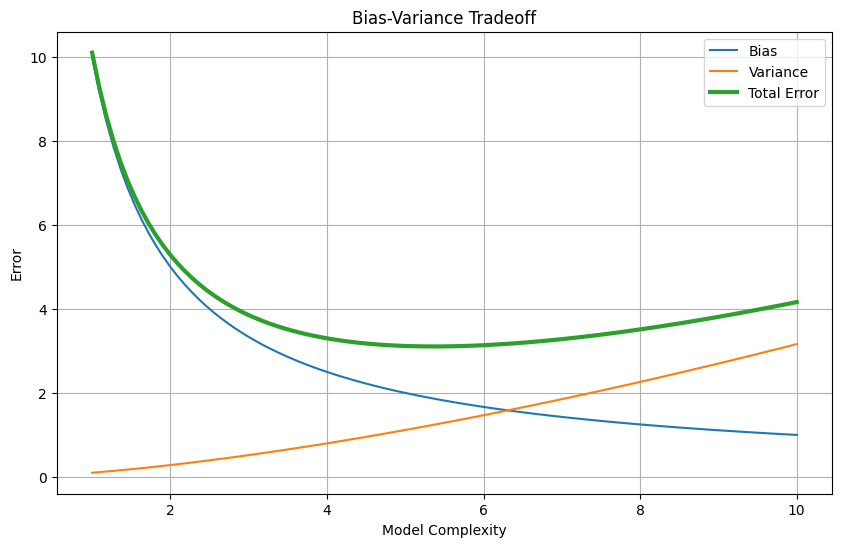

In [13]:
complexity = np.linspace(1, 10, 100)

# Conceptual curves
bias = 10 / complexity
variance = complexity**1.5 / 10

total_error = bias + variance

plt.figure(figsize=(10, 6))

plt.plot(complexity, bias, label="Bias")
plt.plot(complexity, variance, label="Variance")
plt.plot(complexity, total_error, linewidth=3, label="Total Error")

plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias-Variance Tradeoff")

plt.legend()
plt.grid(True)
plt.show()

### Important

The curves above are **illustrative**.

They demonstrate the general idea:

**Model complexity increases → Bias decreases**

**Model complexity increases → Variance increases**

The total error is lowest around the point where the two are reasonably balanced.

## 11. Practical Example

Let's build several polynomial regression models with different complexity levels.

We will compare:

- Degree 1
- Degree 2
- Degree 5
- Degree 15

This will help us visually understand:

- Underfitting
- Good fitting
- Overfitting

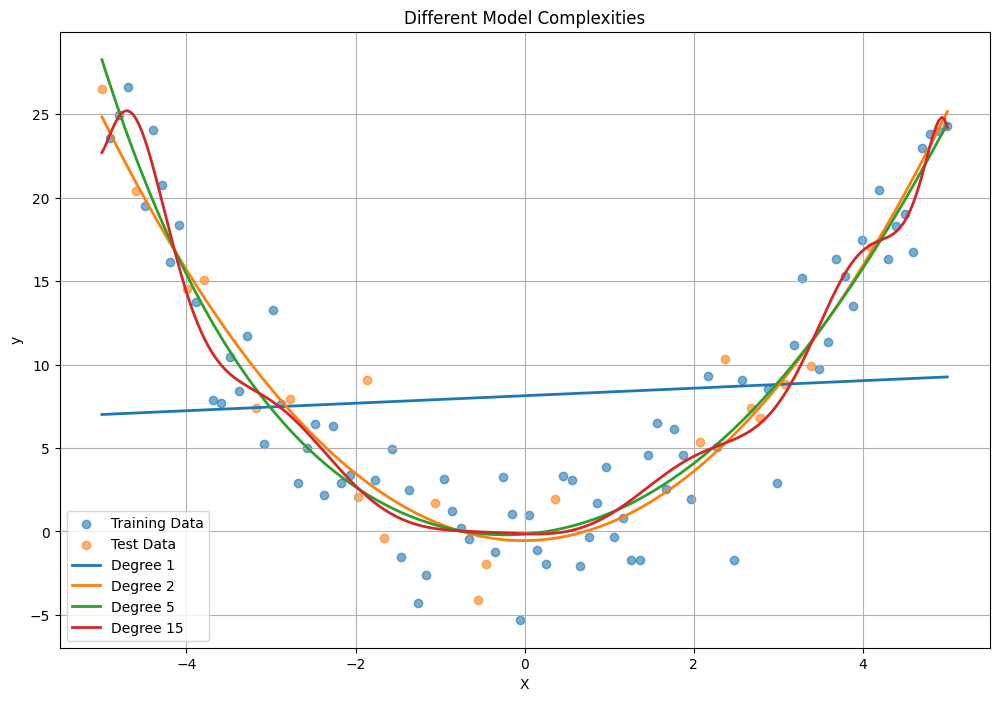

In [14]:
degrees_to_compare = [1, 2, 5, 15]

x_curve = np.linspace(
    X.min(),
    X.max(),
    300
).reshape(-1, 1)

plt.figure(figsize=(12, 8))

plt.scatter(
    X_train,
    y_train,
    alpha=0.6,
    label="Training Data"
)

plt.scatter(
    X_test,
    y_test,
    alpha=0.6,
    label="Test Data"
)

for degree in degrees_to_compare:

    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    prediction = model.predict(x_curve)

    plt.plot(
        x_curve,
        prediction,
        linewidth=2,
        label=f"Degree {degree}"
    )

plt.xlabel("X")
plt.ylabel("y")
plt.title("Different Model Complexities")

plt.legend()
plt.grid(True)
plt.show()

## Compare Models Numerically

In [15]:
model_results = []

for degree in degrees_to_compare:

    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_mse = mean_squared_error(
        y_train,
        train_prediction
    )

    test_mse = mean_squared_error(
        y_test,
        test_prediction
    )

    model_results.append({
        "Polynomial Degree": degree,
        "Training MSE": train_mse,
        "Test MSE": test_mse
    })

model_results_df = pd.DataFrame(model_results)

model_results_df

,Polynomial Degree,Training MSE,Test MSE
0,1,70.235754,58.915877
1,2,7.742320,5.576697
2,5,7.174658,5.842134
3,15,6.437565,7.780348


### Interpretation

A very simple model may have high training and test error.

A very complex model may have:

- Very low training error
- High test error

The best model is generally the one that achieves low test error without unnecessary complexity.

## 13. How to Reduce Bias

High bias means the model is too simple.

We can reduce bias by increasing the model's ability to learn patterns.

### Techniques

1. Use a more complex model
2. Add useful features
3. Add polynomial features
4. Reduce excessive regularization
5. Train the model for longer when appropriate
6. Reduce overly strong assumptions

### Example

A linear model may have high bias for nonlinear data.

We can use polynomial regression instead.

In [16]:
# High-bias linear model

linear_model = make_pipeline(
    PolynomialFeatures(degree=1),
    LinearRegression()
)

# More flexible model

polynomial_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

linear_model.fit(X_train, y_train)
polynomial_model.fit(X_train, y_train)

linear_test_error = mean_squared_error(
    y_test,
    linear_model.predict(X_test)
)

polynomial_test_error = mean_squared_error(
    y_test,
    polynomial_model.predict(X_test)
)

print("Linear Model Test MSE:", linear_test_error)
print("Polynomial Model Test MSE:", polynomial_test_error)

Linear Model Test MSE: 58.91587699531051
Polynomial Model Test MSE: 5.57669740535548


## 14. How to Reduce Variance

High variance means the model is too sensitive to the training data.

We can reduce variance using:

1. More training data
2. A simpler model
3. Regularization
4. Feature selection
5. Cross-validation
6. Ensemble methods such as Random Forest
7. Removing noisy or unnecessary features

### Example

A degree-15 polynomial can overfit the data.

We can reduce variance by using a simpler degree-2 model.

In [17]:
# High variance model

high_variance_model = make_pipeline(
    PolynomialFeatures(degree=15),
    LinearRegression()
)

# Simpler model

lower_variance_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

high_variance_model.fit(X_train, y_train)
lower_variance_model.fit(X_train, y_train)

high_variance_test_error = mean_squared_error(
    y_test,
    high_variance_model.predict(X_test)
)

lower_variance_test_error = mean_squared_error(
    y_test,
    lower_variance_model.predict(X_test)
)

print(
    "High Variance Model Test MSE:",
    high_variance_test_error
)

print(
    "Simpler Model Test MSE:",
    lower_variance_test_error
)

High Variance Model Test MSE: 7.7803480117069865
Simpler Model Test MSE: 5.57669740535548


# 15. Final Summary

## Bias

Bias is error caused by overly simple assumptions.

**High Bias → Underfitting**

---

## Variance

Variance measures how sensitive the model is to changes in training data.

**High Variance → Overfitting**

---

## Bias-Variance Tradeoff

As model complexity increases:

**Bias ↓**

**Variance ↑**

A good model balances both.

---

## Underfitting

- Model too simple
- High Bias
- Usually high training error
- Usually high test error

---

## Good Fit

- Appropriate complexity
- Balanced Bias and Variance
- Low test error
- Good generalization

---

## Overfitting

- Model too complex
- High Variance
- Very low training error
- High test error

---

## Ways to Reduce Bias

- Increase model complexity
- Add useful features
- Reduce excessive regularization
- Use a more powerful model

---

## Ways to Reduce Variance

- Collect more data
- Simplify the model
- Use regularization
- Use cross-validation
- Use ensemble methods
- Remove unnecessary features